Nom : Khadijetou Mohamed abe

Filière : GLCC

# 1. CODE SCRATCH (ID3)

In [28]:
import numpy as np

def sigmoid(z):
    # """
    # σ(z) = 1 / (1 + e^(-z))
    # """
    return 1 / (1 + np.exp(-z))


def calcul_valeur_feuille(g, h, lambda_reg):
    # """
    # Calcule le poids optimal d'une feuille pour XGBoost.
    # w* = - sum(g) / (sum(h) + lambda)
    # g : gradient (erreur de l'itération précédente)
    # h : hessien (p*(1-p), qui représente la variance)
    # """
    # On calcule la somme 
    sum_g = np.sum(g)
    sum_h = np.sum(h)
    # On applique la formule en ajoutant la régularisation L2 (lambda_reg) 
    return -sum_g / (sum_h + lambda_reg)


# construire_arbre_xgb utilise une version modifiée de CART.
def construire_arbre_xgb(X, g, h, depth, max_depth, lambda_reg, gamma):
    # """
    # C'est une fonction récursive qui retourne un dictionnaire imbriqué représentant l'arbre.
    # """
    # Condition d'arrêt : on a atteint la profondeur maximale de l'arbre fixée 
    if depth >= max_depth:
        return {'valeur_feuille': calcul_valeur_feuille(g, h, lambda_reg)}
    
    best_gain = 0
    best_split = None
    
    # Sommes globales des gradients (G) et hessiens (H) pour le noeud courant entier
    G = np.sum(g)
    H = np.sum(h)
    # n_features = nombre de colonnes dans la matrice X
    n_features = X.shape[1]
    
    # On cherche la meilleure division (split) en testant toutes les caractéristiques
    for feature_idx in range(n_features):
        # On extrait la colonne de données correspondant à la caractéristique actuelle
        feature_values = X[:, feature_idx]
        # On récupère les valeurs uniques de cette colonne pour tester chaque seuil possible
        unique_values = np.unique(feature_values)
        
        # Pour chaque valeur unique, on va faire un test de division
        for value in unique_values:
            # Séparation binaire par masque booléen : 
            # branche gauche contient les valeurs inférieures ou égales au seuil
            left_mask = feature_values <= value
            # branche droite contient les valeurs strictement supérieures
            right_mask = feature_values > value
            
            # Si un des côtés est vide (soit tout est à gauche, soit tout est à droite),
            # c'est un split invalide, donc on passe directement à la valeur suivante avec "continue"
            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue
                
            # Sommes partielles des gradients et hessiens pour les éléments de la branche gauche
            GL = np.sum(g[left_mask])
            HL = np.sum(h[left_mask])
            
            # Sommes partielles des gradients et hessiens pour les éléments de la branche droite
            GR = np.sum(g[right_mask])
            HR = np.sum(h[right_mask])
            
            # '''
            # Calcul du score de similarité pour évaluer la qualité du noeud.
            # Formule du Gain d'XGBoost :
            # Gain = 1/2 *[ (GL^2 / (HL + lambda)) + (GR^2 / (HR + lambda)) - (G^2 / (H + lambda)) ] - gamma
            # '''
            # Calcul du score pour l'enfant gauche
            score_left = (GL**2) / (HL + lambda_reg)
            # Calcul du score pour l'enfant droit
            score_right = (GR**2) / (HR + lambda_reg)
            # Calcul du score du noeud parent actuel
            score_parent = (G**2) / (H + lambda_reg)
            
            # Gain final 
            gain = 0.5 * (score_left + score_right - score_parent) - gamma
            
            # Si ce gain est meilleur que notre meilleur gain précédent, on met à jour nos variables
            if gain > best_gain:
                best_gain = gain
                # On stocke l'index de la caractéristique, la valeur seuil, et les masques associés
                best_split = (feature_idx, value, left_mask, right_mask)
                
    # Si on a trouvé une séparation qui améliore le modèle (gain strictement positif)
    if best_gain > 0 and best_split is not None:
        feature_idx, value, left_mask, right_mask = best_split
        
        # Appels récursifs : 
        # pour construire le sous-arbre gauche
        left_branch = construire_arbre_xgb(X[left_mask], g[left_mask], h[left_mask], depth + 1, max_depth, lambda_reg, gamma)
        # pour construire le sous-arbre droit avec right_mask
        right_branch = construire_arbre_xgb(X[right_mask], g[right_mask], h[right_mask], depth + 1, max_depth, lambda_reg, gamma)
        
        # On retourne le noeud courant sous la forme d'un dictionnaire imbriqué
        return {
            'feature_idx': feature_idx,  # Indice de la colonne utilisée pour séparer
            'split_value': value,        # Seuil de séparation
            'left': left_branch,         # Tout le sous-arbre gauche
            'right': right_branch        # Tout le sous-arbre droit
        }
    else:
        # Si aucun split n'a donné de gain positif (soit gain négatif, soit nul),
        # On force le noeud actuel à devenir une feuille terminale
        return {'valeur_feuille': calcul_valeur_feuille(g, h, lambda_reg)}


def predict_un_arbre(arbre, x):
    # """ 
    # Fait descendre une seule observation 'x' dans la structure d'un arbre (dictionnaire)
    # pour obtenir sa prédiction finale.
    # """
    # S'il y a la clé 'valeur_feuille', c'est qu'on est arrivé au feuille
    if 'valeur_feuille' in arbre:
        # on retourne donc le poids de cette feuille
        return arbre['valeur_feuille']
    
    # Sinon, on vérifie si la valeur de 'x' pour la feature concernée est <= au seuil
    if x[arbre['feature_idx']] <= arbre['split_value']:
        # Si c'est le cas, on part récursivement dans la branche gauche
        return predict_un_arbre(arbre['left'], x)
    else:
        # Sinon on dépasse le seuil, on part récursivement dans la branche droite
        return predict_un_arbre(arbre['right'], x)


def xgboost(X, y, n_estimators=5, max_depth=2, learning_rate=0.3, lambda_reg=1.0, gamma=0.0):
    # """ 
    # Algorithme Principal d'XGBoost : 
    # Contrairement aux Random Forests, chaque arbre ici essaie de corriger l'erreur de l'arbre précédent.
    # """

    arbres =[]
    base_pred = np.zeros(len(y))
    
    # On boucle n_estimators fois (nombre d'arbres qu'on veut créer)
    for i in range(n_estimators):
        # Étape 1 : On transforme nos prédictions brutes en probabilités
        p = sigmoid(base_pred)
        # Étape 2 : Calcul du Gradient
        # qui correspond à l'erreur simple : prédiction - vrai label
        g = p - y
        # Étape 3 : Calcul du Hessien 
        # qui correspond à p * (1 - p) dans le cas de la régression logistique
        h = p * (1 - p)

        # Étape 4 : Création d'un arbre d'XGBoost entraîné sur ces gradients (g) et hessiens (h)
        arbre = construire_arbre_xgb(X, g, h, 0, max_depth, lambda_reg, gamma)
        # On ajoute cet arbre fini à notre ensemble (forêt)
        arbres.append(arbre)
        
        # On calcule les prédictions brutes que fait ce NOUVEL arbre pour chaque élément x de notre Dataset X
        predictions_arbre = np.array([predict_un_arbre(arbre, x) for x in X])
        
        # Étape 5 : Mise à jour des prédictions globales accumulées
        base_pred += learning_rate * predictions_arbre
        
    return arbres

## a. DATASET

In [29]:
# Exemple classique : Heures de révision vs Réussite à un examen

# X : Nombre d'heures étudiées (1 à 14 heures)
X_data_xgb = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]).reshape(-1, 1)

# Y : Réussite (0 = Échec, 1 = Succès)
# On ajoute une petite anomalie (à 7h il réussit, à 8h il échoue) pour forcer l'arbre à travailler
y_data_xgb = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1])


## b. Exécution du code scratch

In [30]:
learning_rate_param = 0.3
arbres_scratch_xgb = xgboost(
    X_data_xgb, y_data_xgb, 
    n_estimators=4, 
    max_depth=2, 
    learning_rate=0.3, 
    lambda_reg=1.0
)

# Prédictions directes sur les données brutes
predictions_scratch_xgb = xgboost_predict(arbres_scratch_xgb, X_data_xgb, learning_rate=learning_rate_param)

## c. Code sklearn

In [31]:
from xgboost import XGBClassifier

# On lui passe les mêmes hyperparamètres que ceux de notre code scratch pour pouvoir faire une vraie comparaison
modele_lib_xgb = XGBClassifier(
    n_estimators=4, 
    max_depth=2, 
    learning_rate=0.3, 
    reg_lambda=1.0, 
    gamma=0.0,
    # eval_metric : La fonction de coût à minimiser, ici la 'logloss' classique pour la classification binaire
    eval_metric='logloss'
)

# On entraîne le modèle de la bibliothèque sklearn/xgboost sur nos données
modele_lib_xgb.fit(X_data_xgb, y_data_xgb)

# On obtient les prédictions finales de la bibliothèque
predictions_lib_xgb = modele_lib_xgb.predict(X_data_xgb)

## d. Comparaison et graphiques (scratch/sklearn)


Comparaison de l'Architecture (Premier Arbre de la forêt) :
Arbre Scratch (Arbre n° 1  sur 4) :
|--- Si Feature[0] <= 6.00
│   |--- Poids de la feuille : -1.2
|--- Sinon (> 6.00)
│   |--- Si Feature[0] <= 8.00
│   │   |--- Poids de la feuille : -0.0
│   |--- Sinon (> 8.00)
│   │   |--- Poids de la feuille : 1.2
Arbre Scratch (Arbre n° 2  sur 4) :
|--- Si Feature[0] <= 6.00
│   |--- Poids de la feuille : -1.0054
|--- Sinon (> 6.00)
│   |--- Si Feature[0] <= 8.00
│   │   |--- Poids de la feuille : -0.0
│   |--- Sinon (> 8.00)
│   │   |--- Poids de la feuille : 1.0054
Arbre Scratch (Arbre n° 3  sur 4) :
|--- Si Feature[0] <= 6.00
│   |--- Poids de la feuille : -0.8701
|--- Sinon (> 6.00)
│   |--- Si Feature[0] <= 8.00
│   │   |--- Poids de la feuille : -0.0
│   |--- Sinon (> 8.00)
│   │   |--- Poids de la feuille : 0.8701
Arbre Scratch (Arbre n° 4  sur 4) :
|--- Si Feature[0] <= 6.00
│   |--- Poids de la feuille : -0.7683
|--- Sinon (> 6.00)
│   |--- Si Feature[0] <= 8.00
│   │   |--- Po

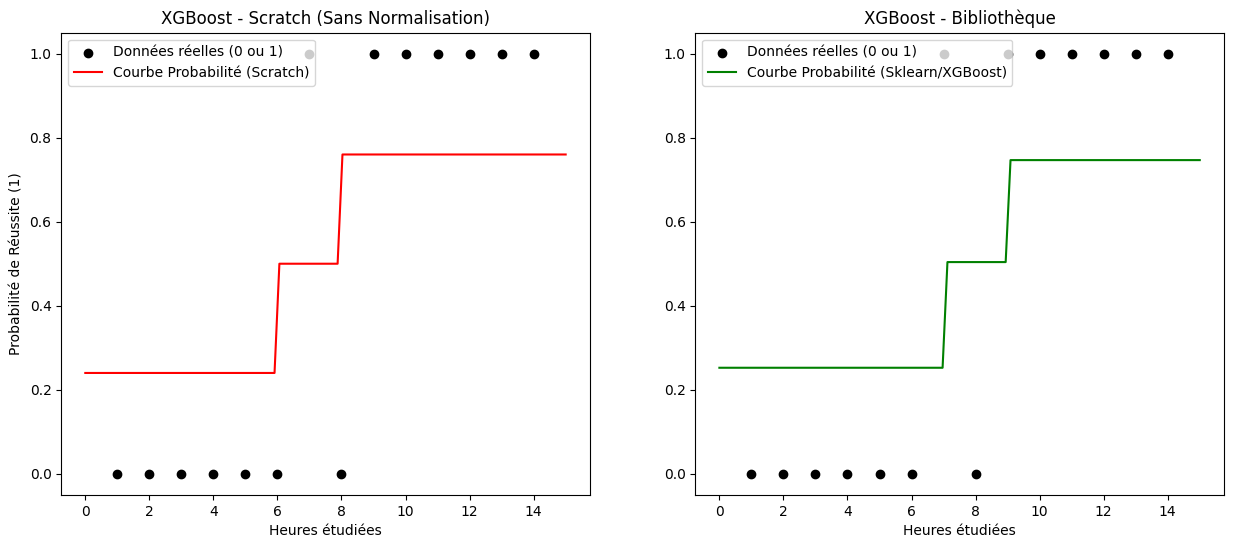

In [32]:
print("\nComparaison de l'Architecture (Premier Arbre de la forêt) :")

for i in range(4):
    print("Arbre Scratch (Arbre n°",i+1," sur 4) :")
    print_xgb_tree(arbres_scratch_xgb[i])

print("\nComparaison des prédictions globales :")
print("Scratch   :", predictions_scratch_xgb)
print("Library   :", predictions_lib_xgb)

import matplotlib.pyplot as plt

# Helpers pour affichage
def xgboost_predict_proba(arbres, X, learning_rate=0.3):
    # """ Calcule la probabilité finale pour chaque observation """
    pred = np.zeros(len(X))
    for arbre in arbres:
        pred += learning_rate * np.array([predict_un_arbre(arbre, x) for x in X])
    return sigmoid(pred)

def xgboost_predict(arbres, X, learning_rate=0.3, seuil=0.5):
    # """ Retourne la classe finale (0 ou 1) """
    probabilites = xgboost_predict_proba(arbres, X, learning_rate)
    return (probabilites >= seuil).astype(int)
    
def print_xgb_tree(tree, indent=""):
    # """ Affiche l'arbre sous forme de texte """
    if 'valeur_feuille' in tree:
        print(indent + "|--- Poids de la feuille : " + str(round(tree['valeur_feuille'], 4)))
        return
    print(indent + f"|--- Si Feature[{tree['feature_idx']}] <= {tree['split_value']:.2f}")
    print_xgb_tree(tree['left'], indent + "│   ")
    print(indent + f"|--- Sinon (> {tree['split_value']:.2f})")
    print_xgb_tree(tree['right'], indent + "│   ")
    
# Graphiques
# On crée de nouvelles données brutes pour l'axe X (de 0 à 15 heures)
X_range = np.linspace(X_data_xgb.min() - 1, X_data_xgb.max() + 1, 100).reshape(-1, 1)

# Plus besoin de scaler, on prédit directement !
probabilites_scratch = xgboost_predict_proba(arbres_scratch_xgb, X_range, learning_rate=learning_rate_param)
probabilites_lib = modele_lib_xgb.predict_proba(X_range)[:, 1]

# Affichage
plt.figure(figsize=(15, 6))

# Graphique Scratch
plt.subplot(1, 2, 1)
plt.scatter(X_data_xgb, y_data_xgb, color='black', label='Données réelles (0 ou 1)')
plt.plot(X_range, probabilites_scratch, 'r', label='Courbe Probabilité (Scratch)')
plt.title('XGBoost - Scratch')
plt.ylabel('Probabilité de Réussite (1)')
plt.xlabel('Heures étudiées')
plt.legend()

# Graphique Bibliotheque
plt.subplot(1, 2, 2)
plt.scatter(X_data_xgb, y_data_xgb, color='black', label='Données réelles (0 ou 1)')
plt.plot(X_range, probabilites_lib, 'g', label='Courbe Probabilité (Sklearn/XGBoost)')
plt.title('XGBoost - Bibliothèque')
plt.xlabel('Heures étudiées')
plt.legend()

plt.show()